<a href="https://colab.research.google.com/github/nabilanisa1504/Pengolahan-Citra/blob/main/JobSheet3_PerbaikanCitraDalamDomainSpasial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

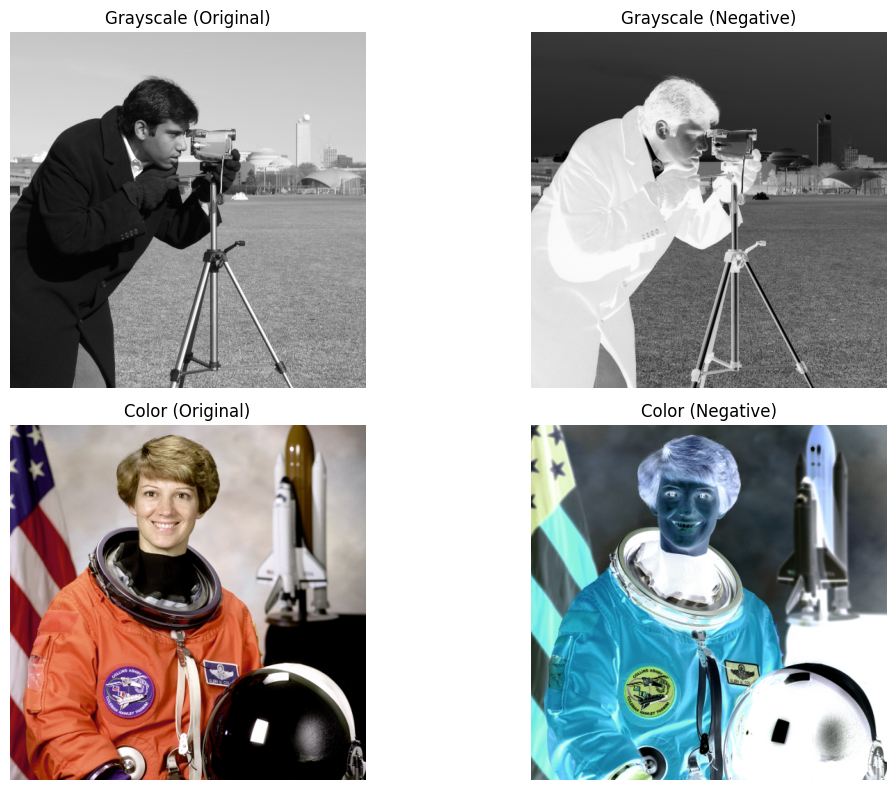

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

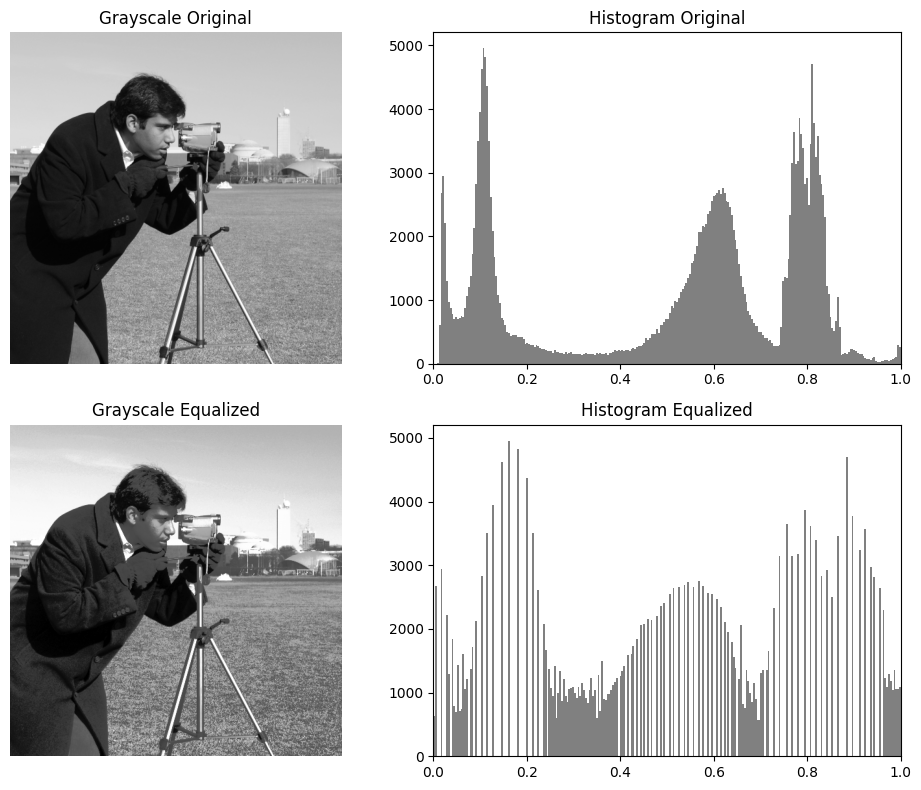

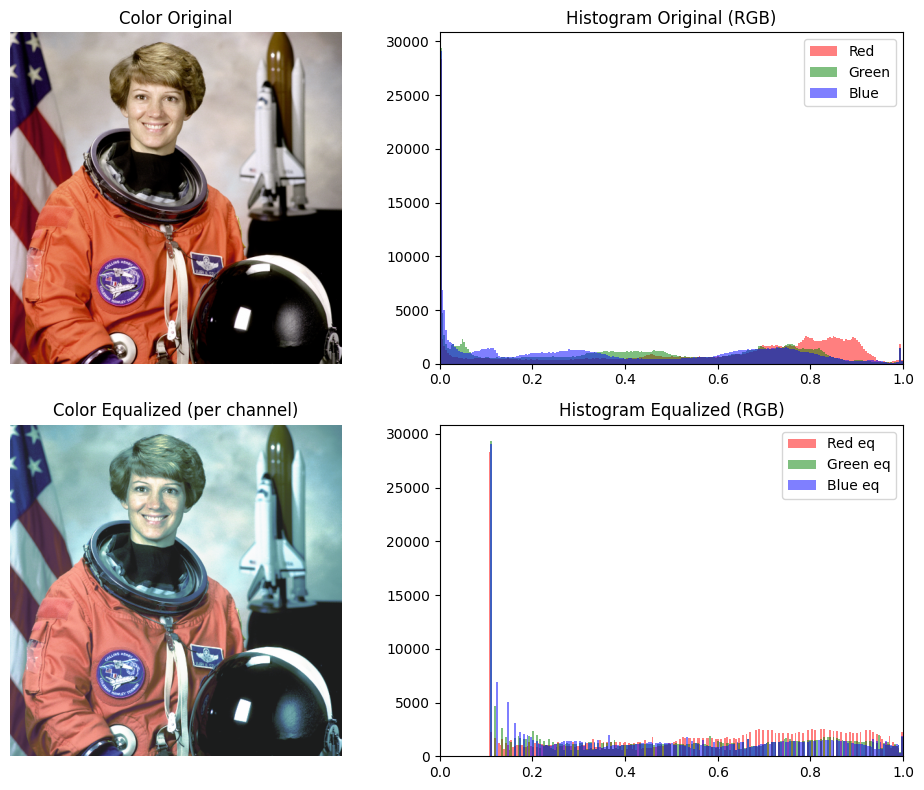

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# -----------------------------------------------------
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# -----------------------------------------------------

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli (dengan numpy.histogram)
#    Kita perbesar bins=256 untuk melihat distribusi piksel
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram
#    Dengan skimage.exposure.equalize_hist, hasil di rentang [0..1]
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# -------------------------------------------------------

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # citra berwarna RGB (uint8)
image_color = img_as_float(image_color_uint8)  # konversi ke float [0..1]

# 2. Kita dapat menghitung histogram gabungan (semua kanal) atau per kanal
#    Di sini kita tampilkan histogram gabungan R, G, B untuk citra asli.
r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

# Hitung histogram untuk tiap kanal, 256 bins
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram tiap kanal secara independen
#    (Catatan: cara ini bisa mengubah keseimbangan warna.
#     Terkadang lebih baik melakukan ekualisasi hanya pada kanal luminance (Y)
#     atau Value (HSV). Tapi di sini kita tunjukkan contoh per kanal.)
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali menjadi citra RGB yang sudah di-ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram citra berwarna ekualisasi (tiap kanal)
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Hasil Ekualisasi (RGB)
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi (tumpuk R, G, B)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

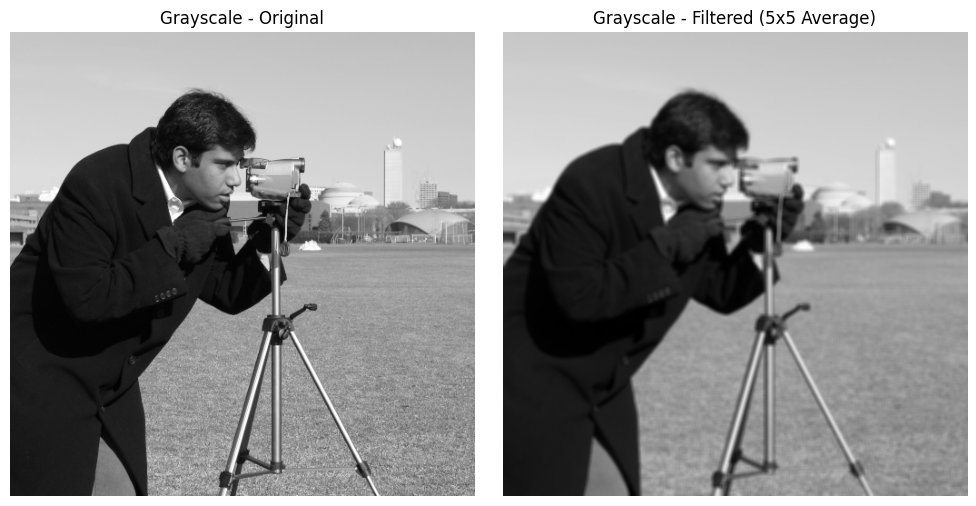

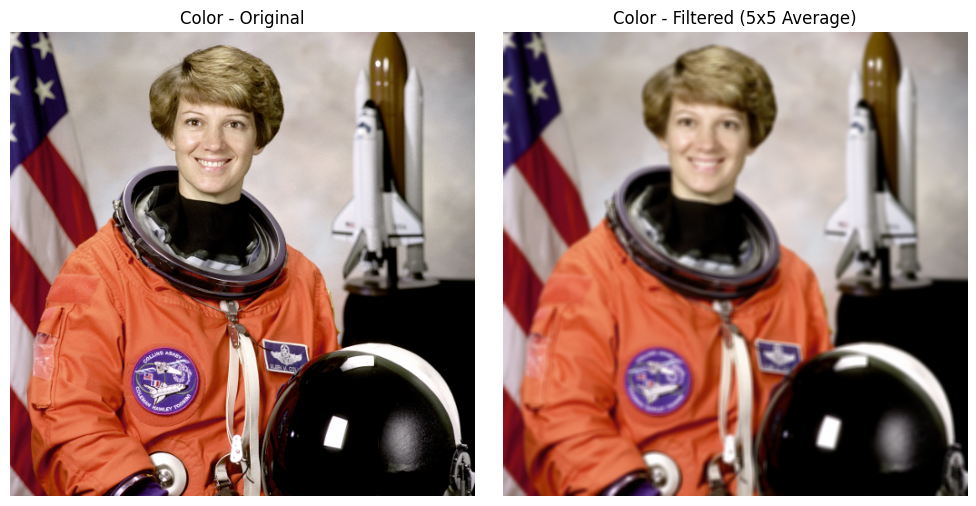

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# --------------------------------------------------
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# --------------------------------------------------

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B
#    secara terpisah, lalu gabungkan.
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

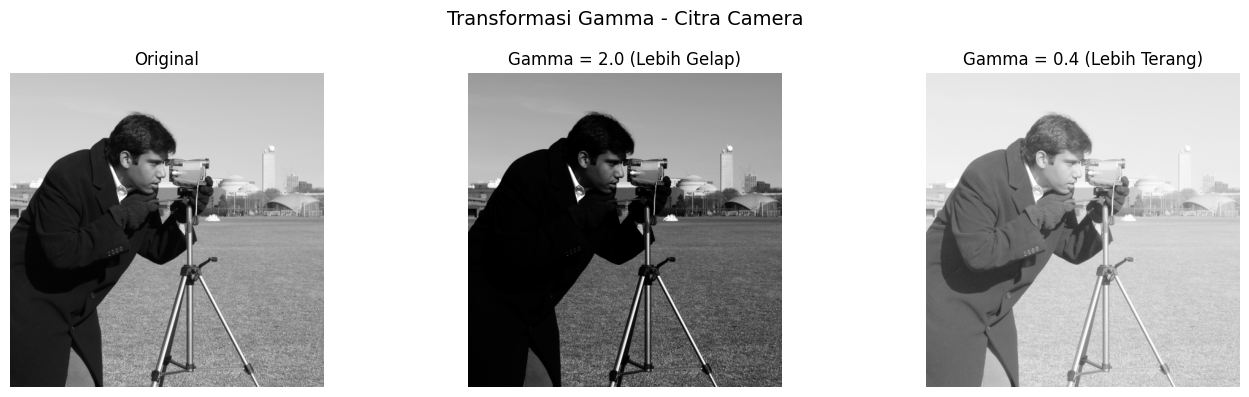

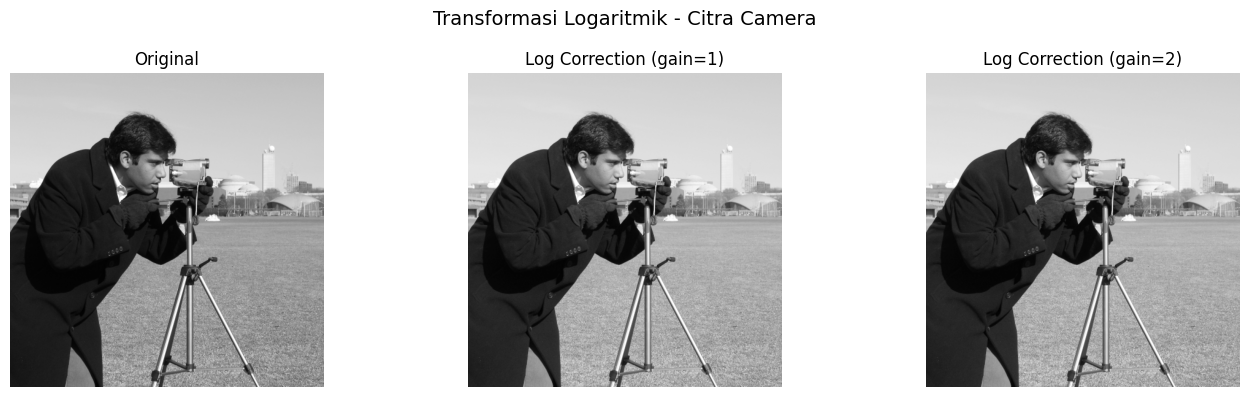

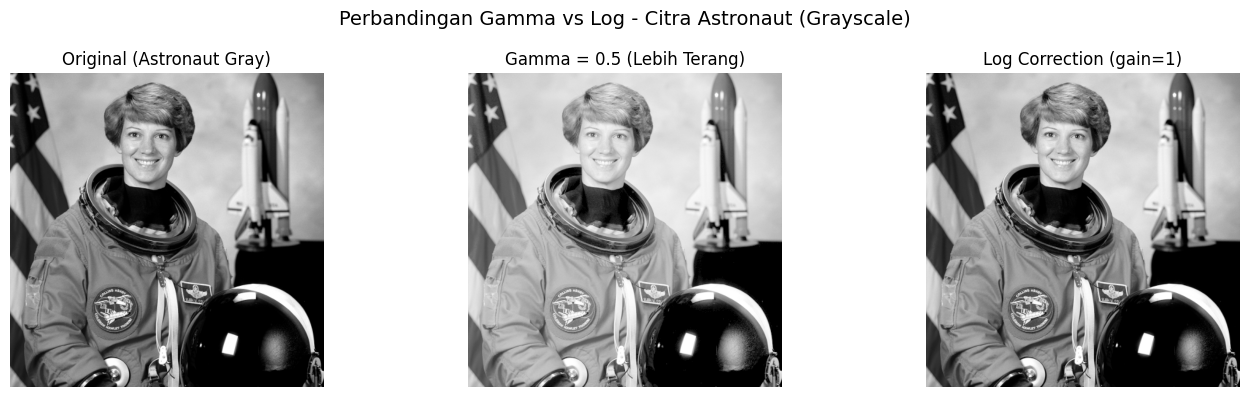

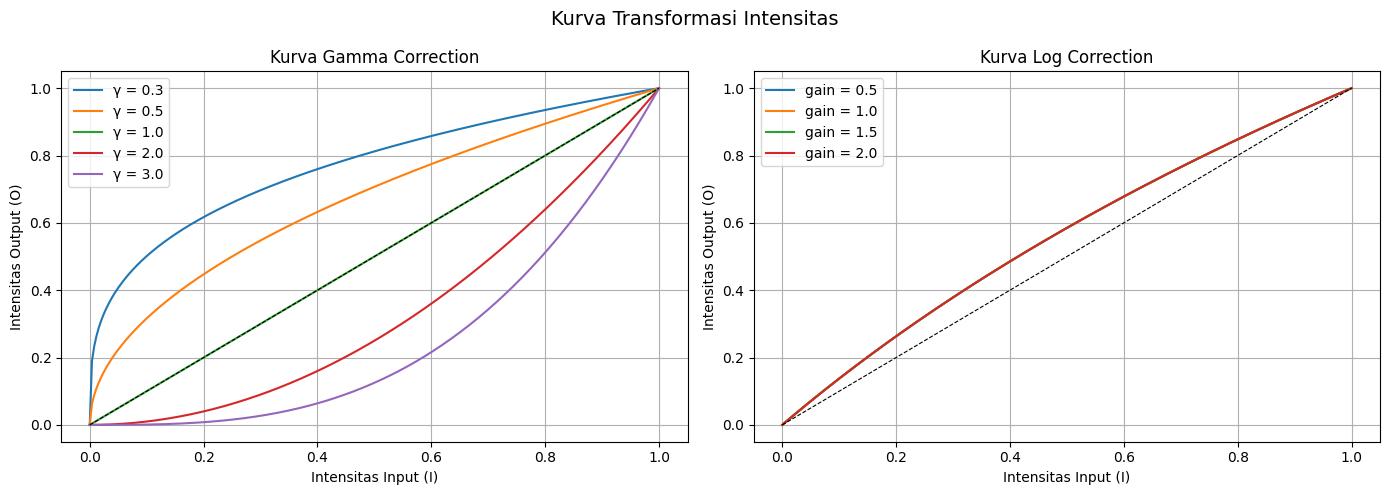

=== Analisis Intensitas Rata-rata (Citra Camera) ===
Original        : 0.5061
Gamma = 2.0     : 0.3396  (lebih gelap dari original)
Gamma = 0.4     : 0.7125  (lebih terang dari original)
Log (gain=1)    : 0.5617
Log (gain=2)    : 1.1235

=== Analisis Intensitas Rata-rata (Citra Astronaut Grayscale) ===
Original        : 0.4420
Gamma = 0.5     : 0.5921
Log (gain=1)    : 0.4959


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color
from skimage import exposure

# =====================================================
# PERSIAPAN: Memuat 2 citra grayscale yang berbeda
# =====================================================

img1 = img_as_float(data.camera())
img2 = img_as_float(color.rgb2gray(data.astronaut()))

# =====================================================
# BAGIAN 1: TRANSFORMASI GAMMA pada img1 (camera)
# =====================================================

gamma_dark   = exposure.adjust_gamma(img1, gamma=2.0)
gamma_bright = exposure.adjust_gamma(img1, gamma=0.4)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Transformasi Gamma - Citra Camera", fontsize=14)

axes[0].imshow(img1, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(gamma_dark, cmap='gray')
axes[1].set_title("Gamma = 2.0 (Lebih Gelap)")
axes[1].axis('off')

axes[2].imshow(gamma_bright, cmap='gray')
axes[2].set_title("Gamma = 0.4 (Lebih Terang)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 2: TRANSFORMASI LOGARITMIK pada img1 (camera)
# =====================================================

log_c1 = exposure.adjust_log(img1, gain=1)
log_c2 = exposure.adjust_log(img1, gain=2)

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle("Transformasi Logaritmik - Citra Camera", fontsize=14)

axes2[0].imshow(img1, cmap='gray')
axes2[0].set_title("Original")
axes2[0].axis('off')

axes2[1].imshow(log_c1, cmap='gray')
axes2[1].set_title("Log Correction (gain=1)")
axes2[1].axis('off')

axes2[2].imshow(log_c2, cmap='gray')
axes2[2].set_title("Log Correction (gain=2)")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 3: PERBANDINGAN GAMMA & LOG pada img2 (astronaut grayscale)
# =====================================================

gamma_b2 = exposure.adjust_gamma(img2, gamma=0.5)
log_b2   = exposure.adjust_log(img2, gain=1)

fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4))
fig3.suptitle("Perbandingan Gamma vs Log - Citra Astronaut (Grayscale)", fontsize=14)

axes3[0].imshow(img2, cmap='gray')
axes3[0].set_title("Original (Astronaut Gray)")
axes3[0].axis('off')

axes3[1].imshow(gamma_b2, cmap='gray')
axes3[1].set_title("Gamma = 0.5 (Lebih Terang)")
axes3[1].axis('off')

axes3[2].imshow(log_b2, cmap='gray')
axes3[2].set_title("Log Correction (gain=1)")
axes3[2].axis('off')

plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 4: KURVA TRANSFORMASI (ANALISIS VISUAL)
# =====================================================

x = np.linspace(0, 1, 256)  # input intensitas 0..1

# Kurva Gamma
gamma_vals = [0.3, 0.5, 1.0, 2.0, 3.0]

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle("Kurva Transformasi Intensitas", fontsize=14)

for g in gamma_vals:
    y = x ** g
    axes4[0].plot(x, y, label=f"γ = {g}")

axes4[0].set_title("Kurva Gamma Correction")
axes4[0].set_xlabel("Intensitas Input (I)")
axes4[0].set_ylabel("Intensitas Output (O)")
axes4[0].legend()
axes4[0].grid(True)
axes4[0].plot([0,1],[0,1], 'k--', linewidth=0.8, label='Identitas')

# Kurva Logaritmik
gain_vals = [0.5, 1.0, 1.5, 2.0]

for g in gain_vals:
    y = g * np.log1p(x)          # O = gain * log(1 + I)
    y = y / y.max()               # normalisasi ke [0,1]
    axes4[1].plot(x, y, label=f"gain = {g}")

axes4[1].set_title("Kurva Log Correction")
axes4[1].set_xlabel("Intensitas Input (I)")
axes4[1].set_ylabel("Intensitas Output (O)")
axes4[1].legend()
axes4[1].grid(True)
axes4[1].plot([0,1],[0,1], 'k--', linewidth=0.8, label='Identitas')

plt.tight_layout()
plt.show()

# =====================================================
# ANALISIS: Print nilai rata-rata intensitas
# =====================================================

print("=== Analisis Intensitas Rata-rata (Citra Camera) ===")
print(f"Original        : {img1.mean():.4f}")
print(f"Gamma = 2.0     : {gamma_dark.mean():.4f}  (lebih gelap dari original)")
print(f"Gamma = 0.4     : {gamma_bright.mean():.4f}  (lebih terang dari original)")
print(f"Log (gain=1)    : {log_c1.mean():.4f}")
print(f"Log (gain=2)    : {log_c2.mean():.4f}")

print("\n=== Analisis Intensitas Rata-rata (Citra Astronaut Grayscale) ===")
print(f"Original        : {img2.mean():.4f}")
print(f"Gamma = 0.5     : {gamma_b2.mean():.4f}")
print(f"Log (gain=1)    : {log_b2.mean():.4f}")

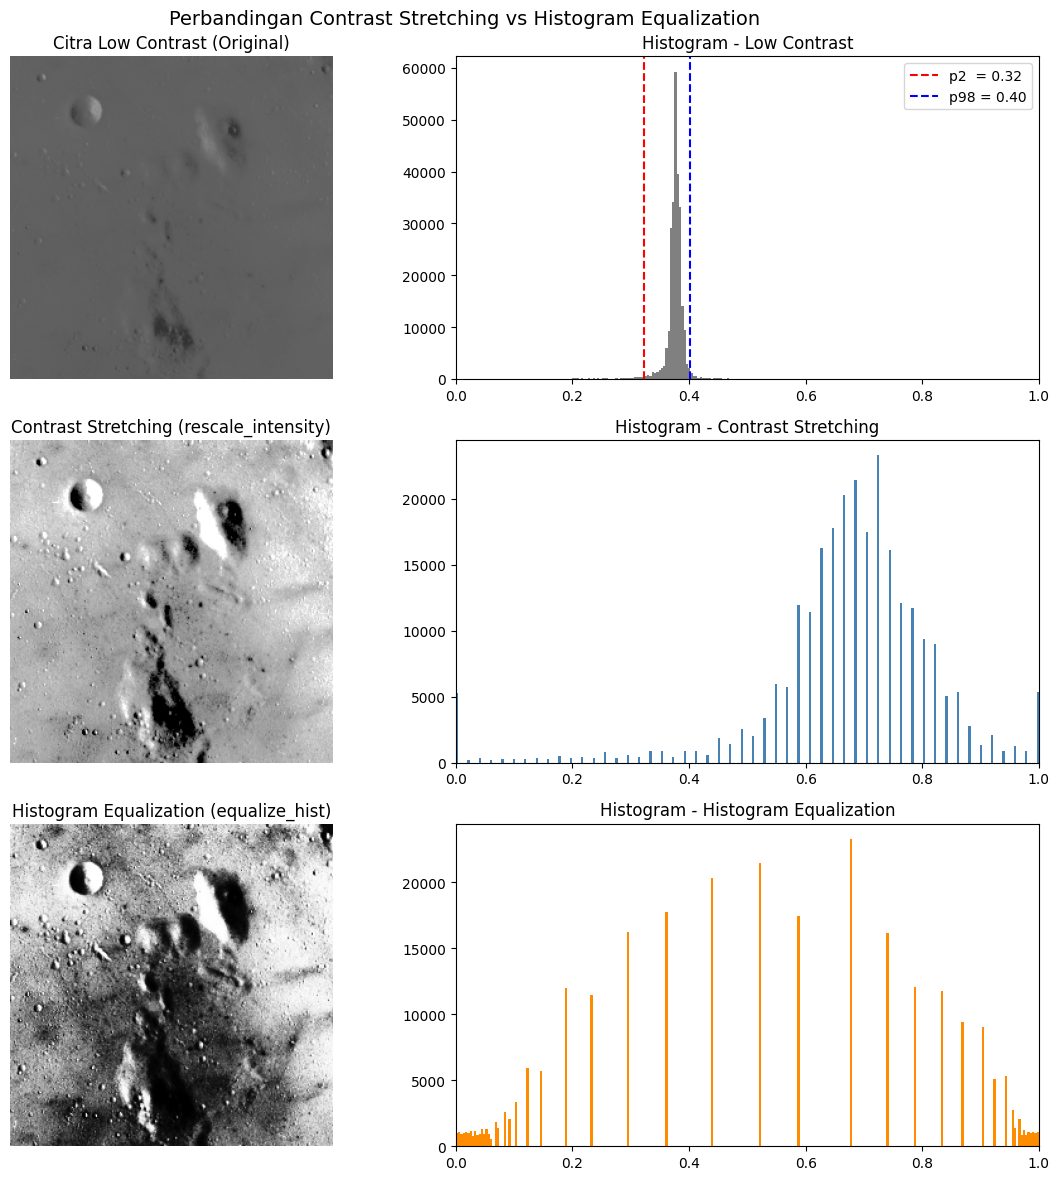

=== Analisis Intensitas ===
Low Contrast  - Mean: 0.3760 | Std: 0.0209 | Min: 0.2000 | Max: 0.6000
Cont. Stretch - Mean: 0.6726 | Std: 0.1658 | Min: 0.0000 | Max: 1.0000
Hist. Equal.  - Mean: 0.5224 | Std: 0.2899 | Min: 0.0009 | Max: 1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure

# =====================================================
# PERSIAPAN: Buat citra grayscale kontras rendah
# =====================================================

# Pakai citra moon (cenderung gelap & kontras rendah)
img = img_as_float(data.moon())

# Simulasi citra low contrast: paksakan rentang intensitas jadi sempit (0.2 - 0.6)
img_lowcontrast = exposure.rescale_intensity(img, out_range=(0.2, 0.6))

# =====================================================
# BAGIAN 1: CONTRAST STRETCHING
# =====================================================

# Ambil persentil 2 dan 98 sebagai batas in_range (lebih robust dari min/max)
p2, p98 = np.percentile(img_lowcontrast, (2, 98))
img_stretched = exposure.rescale_intensity(img_lowcontrast, in_range=(p2, p98))

# =====================================================
# BAGIAN 2: HISTOGRAM EQUALIZATION
# =====================================================

img_equalized = exposure.equalize_hist(img_lowcontrast)

# =====================================================
# BAGIAN 3: TAMPILKAN CITRA + HISTOGRAM
# =====================================================

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Perbandingan Contrast Stretching vs Histogram Equalization", fontsize=14)

# --- Baris 1: Citra Low Contrast ---
axes[0, 0].imshow(img_lowcontrast, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("Citra Low Contrast (Original)")
axes[0, 0].axis('off')

axes[0, 1].hist(img_lowcontrast.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram - Low Contrast")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].axvline(p2,  color='red',  linestyle='--', label=f'p2  = {p2:.2f}')
axes[0, 1].axvline(p98, color='blue', linestyle='--', label=f'p98 = {p98:.2f}')
axes[0, 1].legend()

# --- Baris 2: Contrast Stretching ---
axes[1, 0].imshow(img_stretched, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title("Contrast Stretching (rescale_intensity)")
axes[1, 0].axis('off')

axes[1, 1].hist(img_stretched.ravel(), bins=256, range=(0, 1), color='steelblue')
axes[1, 1].set_title("Histogram - Contrast Stretching")
axes[1, 1].set_xlim(0, 1)

# --- Baris 3: Histogram Equalization ---
axes[2, 0].imshow(img_equalized, cmap='gray', vmin=0, vmax=1)
axes[2, 0].set_title("Histogram Equalization (equalize_hist)")
axes[2, 0].axis('off')

axes[2, 1].hist(img_equalized.ravel(), bins=256, range=(0, 1), color='darkorange')
axes[2, 1].set_title("Histogram - Histogram Equalization")
axes[2, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 4: ANALISIS INTENSITAS
# =====================================================

print("=== Analisis Intensitas ===")
print(f"Low Contrast  - Mean: {img_lowcontrast.mean():.4f} | Std: {img_lowcontrast.std():.4f} | Min: {img_lowcontrast.min():.4f} | Max: {img_lowcontrast.max():.4f}")
print(f"Cont. Stretch - Mean: {img_stretched.mean():.4f} | Std: {img_stretched.std():.4f} | Min: {img_stretched.min():.4f} | Max: {img_stretched.max():.4f}")
print(f"Hist. Equal.  - Mean: {img_equalized.mean():.4f} | Std: {img_equalized.std():.4f} | Min: {img_equalized.min():.4f} | Max: {img_equalized.max():.4f}")

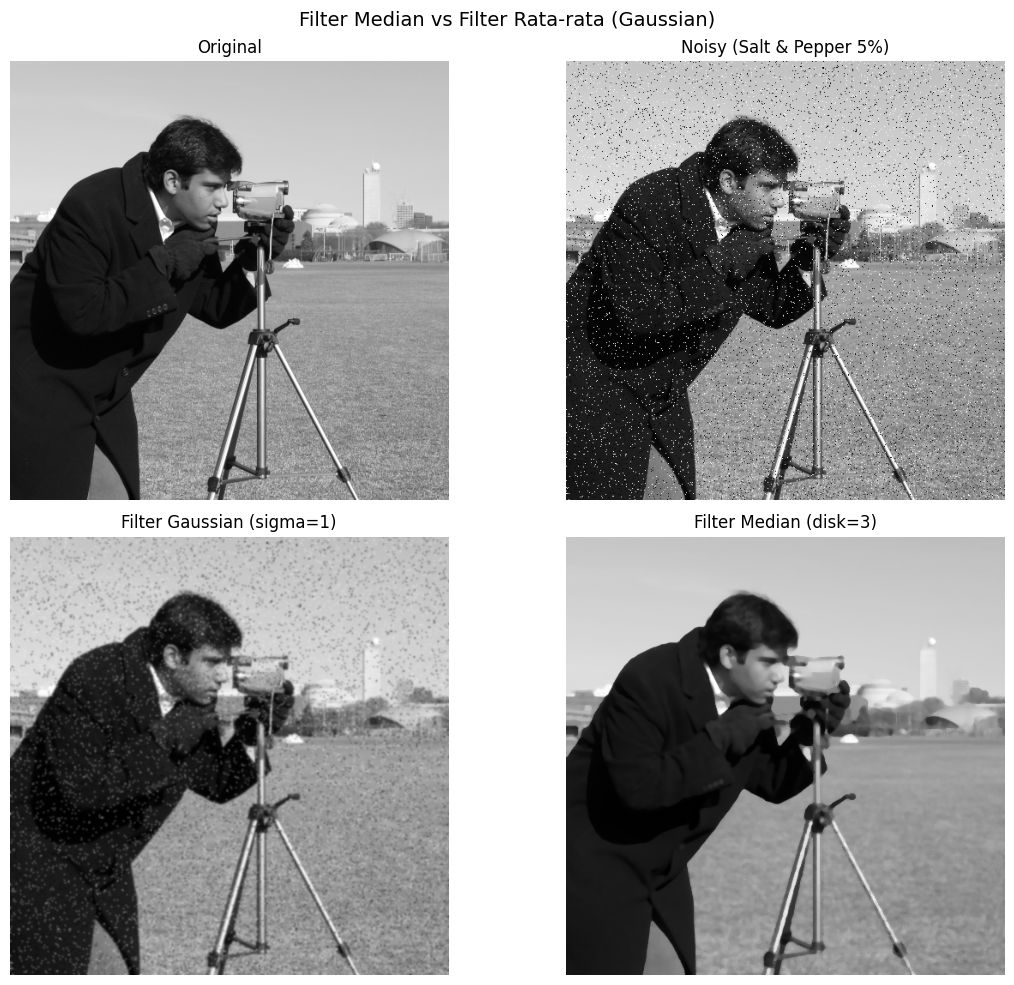

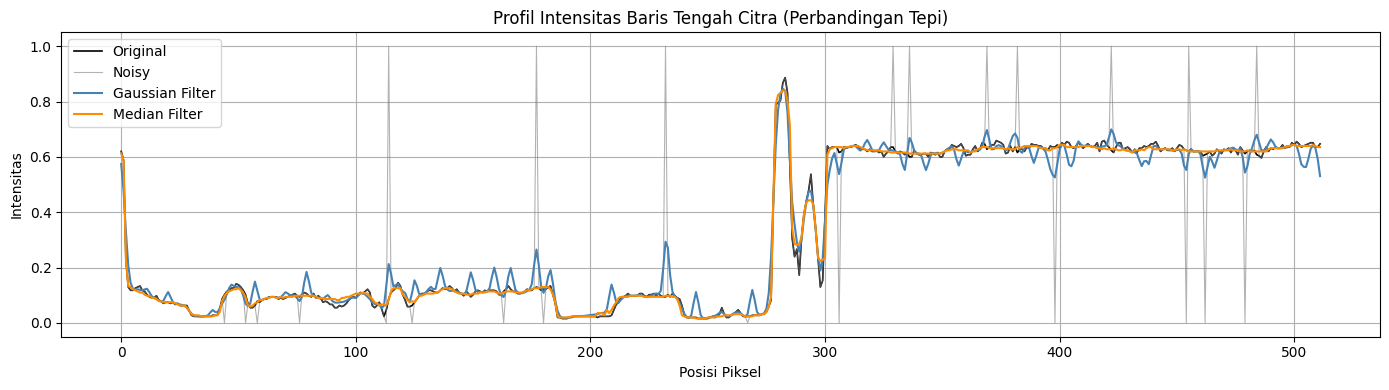

=== Metrik Kualitas Citra ===
                            MSE    PSNR (dB)
Noisy vs Original      0.016642      17.7879
Gaussian vs Original   0.002697      25.6908
Median vs Original     0.001716      27.6549


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, util, filters, morphology
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# =====================================================
# PERSIAPAN: Muat citra & tambahkan noise
# =====================================================

img = img_as_float(data.camera())
img_noisy = util.random_noise(img, mode='s&p', amount=0.05)

# =====================================================
# BAGIAN 1: FILTER RATA-RATA (GAUSSIAN)
# =====================================================

img_gaussian = filters.gaussian(img_noisy, sigma=1)

# =====================================================
# BAGIAN 2: FILTER MEDIAN
# =====================================================

img_median = filters.median(img_noisy, morphology.disk(3))

# =====================================================
# BAGIAN 3: TAMPILKAN CITRA
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Filter Median vs Filter Rata-rata (Gaussian)", fontsize=14)

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_noisy, cmap='gray')
axes[0, 1].set_title("Noisy (Salt & Pepper 5%)")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_gaussian, cmap='gray')
axes[1, 0].set_title("Filter Gaussian (sigma=1)")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_median, cmap='gray')
axes[1, 1].set_title("Filter Median (disk=3)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 4: KURVA PROFIL INTENSITAS (analisis tepi)
# =====================================================

# Ambil 1 baris piksel di tengah citra untuk melihat profil tepi
row = img.shape[0] // 2

fig2, ax = plt.subplots(figsize=(14, 4))
ax.plot(img[row, :],        color='black',      linewidth=1.2, label='Original')
ax.plot(img_noisy[row, :],  color='gray',       linewidth=0.8, alpha=0.6, label='Noisy')
ax.plot(img_gaussian[row, :], color='steelblue', linewidth=1.5, label='Gaussian Filter')
ax.plot(img_median[row, :], color='darkorange',  linewidth=1.5, label='Median Filter')
ax.set_title("Profil Intensitas Baris Tengah Citra (Perbandingan Tepi)")
ax.set_xlabel("Posisi Piksel")
ax.set_ylabel("Intensitas")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 5: METRIK KUALITAS (MSE & PSNR)
# =====================================================

print("=== Metrik Kualitas Citra ===")
print(f"{'':20} {'MSE':>10} {'PSNR (dB)':>12}")
print(f"{'Noisy vs Original':20} {mse(img, img_noisy):>10.6f} {psnr(img, img_noisy):>12.4f}")
print(f"{'Gaussian vs Original':20} {mse(img, img_gaussian):>10.6f} {psnr(img, img_gaussian):>12.4f}")
print(f"{'Median vs Original':20} {mse(img, img_median):>10.6f} {psnr(img, img_median):>12.4f}")